# 1. Analyze data
Dataset:
- Image size: 64 × 64
- Num of timesteps: 2122
- 10 actions (forward, left, back, right, jump, sneak, sprint, attack, horizontal camera change, vertical camera change)
- Actions Dimensions (2122, )
- Camera Dimensions (2122, 2)

ex:
```
$action$forward = [1, 1, 1, ..., 0, 0, 0]
$action$left = [1, 0, 1, ..., 0, 1, 0]
```

We must translate this a (2122, 10) dimension vector:
```
timestamp0 = [1, 0, 0, 0, 0, 0, 0, 0, -0.15, 0.15]
...
```


In [8]:
import cv2
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import concurrent.futures
import os
import time
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


In [ ]:


data_path = Path('data/MineRLTreechop-v0')

# load action samples
sample_dirs = sorted([p for p in data_path.iterdir() if p.is_dir()])

# load first sample
if sample_dirs:
    npz = np.load(sample_dirs[0] / 'rendered.npz')
    print(npz)
    # extract actions as a dictionary
    action_keys = [k for k in npz.keys() if k.startswith('action')]
    actions = {k: npz[k] for k in action_keys}

    print(f"actions: {actions}")
else:
    print(f"no actions for {sample_dirs[0]}")

NpzFile 'data/MineRLTreechop-v0/v3_absolute_grape_changeling-15_10696-12887/rendered.npz' with keys: reward, action$forward, action$left, action$back, action$right...
actions: {'action$forward': array([1, 1, 1, ..., 0, 0, 0], shape=(2122,)), 'action$left': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$back': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$right': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$jump': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$sneak': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$sprint': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$attack': array([0, 0, 0, ..., 1, 1, 1], shape=(2122,)), 'action$camera': array([[-0.14999998,  0.15000153],
       [-0.        ,  0.15000153],
       [ 0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ],
       [ 0.        ,  0.        ],
       [ 1.3500004 , -0.75      ]], shape=(2122, 2), dtype=float32)}


# 2. Preprocess for LeWM
 - Decode frames from recording
 - Action stacking: organize data as timestamp arrays of actions

 * Note the number of frames slightly mismatches with the number of timestamps.

In [ ]:

# ======= Helpers ======= 
def load_video_frames(video_path: str):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)

    frames = []
    f_times = []
    f_index = 0

    while True:
        # read each frame sequentially
        # ret is a boolean indicating if retrieval was successful
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)
        # cv2.imshow('frame_bgr', frame_rgb)
        f_times.append(f_index / fps)
        f_index += 1
    
    print(f"fps: {fps}")
    print(f"num frames: {len(frames)}")
    print(f"frame times: {f_times[:20]}")
    
def process_sample(s):
    timestamps_with_actions = []

    npz = np.load(s / 'rendered.npz')
    video = load_video_frames( s / 'recording.mp4')
    with open(s/'metadata.json', 'r') as f:
        metadata = json.load(f)
    
    # Load actions
    action_keys = [k for k in npz.keys() if k.startswith('action') and k != 'action$camera'] # left, right, etc
    actions = {k: npz[k] for k in action_keys} 

    # Iterate over the action value at each timestamp t. assuming all action array have the 
    # same number of action values (2122)
    for t in range(len(actions['action$left'])):
        # get value for each action at each timestep
        step = np.array([actions[k][t] for k in action_keys])
        timestamps_with_actions.append(step)

    # normalize into numpy array
    actions_np = np.stack(timestamps_with_actions).astype(np.float32)
    print("actions", actions_np[:20])
    print(f"num of timesteps: {len(actions_np)}")

    # save to original folder
    print("location save", s/'actions.npy')
    np.save(s / 'actions.npy', actions_np)

# ======= Load all samples in parallel ======= 
start_time = time.perf_counter()

with concurrent.futures.ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # map futures to each data sample
    future_to_sample = {executor.submit(process_sample, s): s for s in sample_dirs}
    for future in concurrent.futures.as_completed(future_to_sample):
        s = future_to_sample[future] # map completed processing output to original sample
        try:
            data = future.result()
        except Exception as e:
            print(f"error {e}")
end_time = time.perf_counter()
print(f"total wall clock {end_time-start_time} seconds")



fps: 20.0
num frames: 2079
frame times: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
fps: 20.0
num frames: 2052
frame times: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
fps: 20.0
num frames: 2192
frame times: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
actions [[1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]

action [1. 1. 0. 0. 0. 0. 0. 1.]


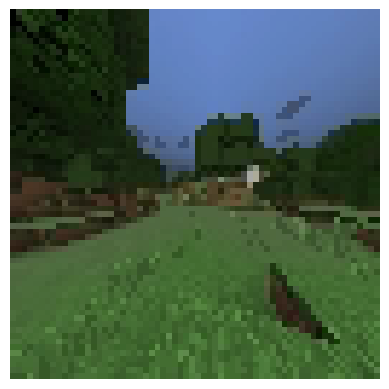

In [24]:
# get the action at timestamp 
sample_dir = Path('data/MineRLTreechop-v0/v3_absolute_grape_changeling-7_14600-16079')
t = 23

# get action
actions = np.load(sample_dir / 'actions.npy')
print("action", actions[t])

# get video frame
cap=cv2.VideoCapture(str(sample_dir / 'recording.mp4'))
cap.set(cv2.CAP_PROP_POS_FRAMES, t)
ret, frame_bgr = cap.read()
cap.release()
if not ret:
    print(f"Could not read frame {t}")
else:
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()